In [8]:
# =========================================================
# MODULE 1 — CONFIGURATION
# =========================================================

import os
import numpy as np
import tensorflow as tf

# -------------------------------
# General Settings
# -------------------------------
IMAGE_SIZE = 128
CHANNELS = 3
NUM_CLASSES = 7   # 0-6 as defined in specification
LATENT_DIM = 100

BATCH_SIZE = 64
EPOCHS = 50

# -------------------------------
# Optimizer Settings
# -------------------------------
LEARNING_RATE = 2e-4
BETA_1 = 0.5
BETA_2 = 0.999

# -------------------------------
# Directories
# -------------------------------
DATA_DIR = r"C:\Users\drsas\Project5\Rawdata\SurfaceDefectDataNew\DAGM_KaggleCombined"
CHECKPOINT_DIR = r"C:\Users\drsas\Project5\CheckPoints"
SAMPLE_DIR = r"C:\Users\drsas\Project5\Samples"
LOG_DIR = r"C:\Users\drsas\Project5\Logs"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAMPLE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# -------------------------------
# Label Mapping
# -------------------------------
LABEL_MAP = {
    0: "Normal",
    1: "Scratch",
    2: "Crack",
    3: "Dent",
    4: "Pit",
    5: "Rust",
    6: "Stain"
}

print("Configuration Loaded Successfully")


Configuration Loaded Successfully


In [9]:
# =========================================================
# MODULE 2 — DATA LOADING & PREPROCESSING
# =========================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

def load_surface_data():
    datagen = ImageDataGenerator(
        rescale=1./127.5,
        preprocessing_function=lambda x: x - 1.0
    )

    generator = datagen.flow_from_directory(
        DATA_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='sparse',
        shuffle=True
    )

    return generator

train_data = load_surface_data()
print("Data Loader Ready")


Found 3450 images belonging to 2 classes.
Data Loader Ready


In [10]:
# =========================================================
# MODULE 3 — GENERATOR
# =========================================================

from tensorflow.keras import layers, Model

def build_generator():

    noise_input = layers.Input(shape=(LATENT_DIM,))
    label_input = layers.Input(shape=(1,), dtype='int32')

    label_embedding = layers.Embedding(NUM_CLASSES, 16)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    combined = layers.Concatenate()([noise_input, label_embedding])

    x = layers.Dense(8 * 8 * 256)(combined)
    x = layers.Reshape((8, 8, 256))(x)

    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    for filters in [256, 128, 64, 32]:
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

    output = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh')(x)

    return Model([noise_input, label_input], output, name="Generator")

generator = build_generator()
generator.summary()


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 1, 16)             │             112 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_5 (InputLayer)    │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_2 (Flatten)           │ (None, 16)                │               0 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 116)               │               0 │ input_layer_5[0][0],       │
│                               │                           │                 │ flatten_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 16384)             │       1,916,928 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_1 (Reshape)           │ (None, 8, 8, 256)         │               0 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_5         │ (None, 8, 8, 256)         │           1,024 │ reshape_1[0][0]            │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_5 (ReLU)                │ (None, 8, 8, 256)         │               0 │ batch_normalization_5[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_4            │ (None, 16, 16, 256)       │       1,048,832 │ re_lu_5[0][0]              │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_6         │ (None, 16, 16, 256)       │           1,024 │ conv2d_transpose_4[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ re_lu_6 (ReLU)                │ (None, 16, 16, 256)       │               0 │ batch_normalization_6[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_5            │ (None, 32, 32, 128)       │         524,416 │ re_lu_6[0][0]              │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_7         │ (None, 32, 32, 128)       │             512 │ conv2d_transpose_5[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 3,658,035 (13.95 MB)

 Trainable params: 3,656,563 (13.95 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [11]:
# =========================================================
# MODULE 4 — DISCRIMINATOR
# =========================================================

def build_discriminator():

    image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))

    x = image_input

    for filters in [64, 128, 256, 512]:
        x = layers.Conv2D(filters, 4, strides=2, padding='same')(x)
        x = layers.LeakyReLU(0.2)(x)
        x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)

    validity = layers.Dense(1, activation='sigmoid')(x)
    label = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(image_input, [validity, label], name="Discriminator")

discriminator = build_discriminator()
discriminator.summary()


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 64, 64, 64)        │           3,136 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU)     │ (None, 64, 64, 64)        │               0 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 64, 64, 64)        │               0 │ leaky_re_lu_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 32, 32, 128)       │         131,200 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU)     │ (None, 32, 32, 128)       │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_5 (Dropout)           │ (None, 32, 32, 128)       │               0 │ leaky_re_lu_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 16, 16, 256)       │         524,544 │ dropout_5[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU)     │ (None, 16, 16, 256)       │               0 │ conv2d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 16, 16, 256)       │               0 │ leaky_re_lu_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 8, 8, 512)         │       2,097,664 │ dropout_6[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_7 (LeakyReLU)     │ (None, 8, 8, 512)         │               0 │ conv2d_9[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 8, 8, 512)         │               0 │ leaky_re_lu_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_3 (Flatten)           │ (None, 32768)             │               0 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 1)                 │          32,769 │ flatten_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 7)                 │         229,383 │ flatten_3[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 3,018,696 (11.52 MB)

 Trainable params: 3,018,696 (11.52 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# =========================================================
# MODULE 5 — MONITORING & CONTROL (Keras 3 FIX)
# =========================================================

# -----------------------------------------
# 1️⃣ Separate Optimizers
# -----------------------------------------
optimizer_d = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

optimizer_g = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=BETA_1,
    beta_2=BETA_2
)

# -----------------------------------------
# 2️⃣ Compile Discriminator
# -----------------------------------------
discriminator.trainable = True

discriminator.compile(
    optimizer=optimizer_d,
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy'],
    metrics=['accuracy', 'accuracy']
)

# -----------------------------------------
# 3️⃣ Build Combined Model
# -----------------------------------------
discriminator.trainable = False

noise_input = layers.Input(shape=(LATENT_DIM,))
label_input = layers.Input(shape=(1,))

generated_image = generator([noise_input, label_input])
validity, target_label = discriminator(generated_image)

combined_model = Model([noise_input, label_input], [validity, target_label])

combined_model.compile(
    optimizer=optimizer_g,
    loss=['binary_crossentropy', 'sparse_categorical_crossentropy']
)

print("Monitoring & Control Ready (Keras 3 Compatible)")


Monitoring & Control Ready (Keras 3 Compatible)


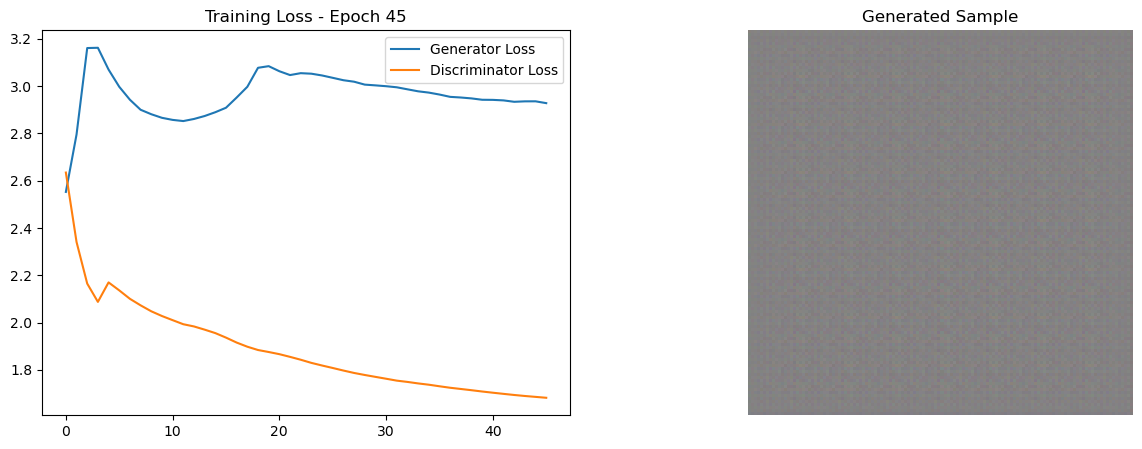

Epoch 45/50 | D: 1.6819 | G: 2.9283
Epoch 46/50 | D: 1.6783 | G: 2.9253
Epoch 47/50 | D: 1.6748 | G: 2.9231
Epoch 48/50 | D: 1.6712 | G: 2.9217
Epoch 49/50 | D: 1.6677 | G: 2.9179


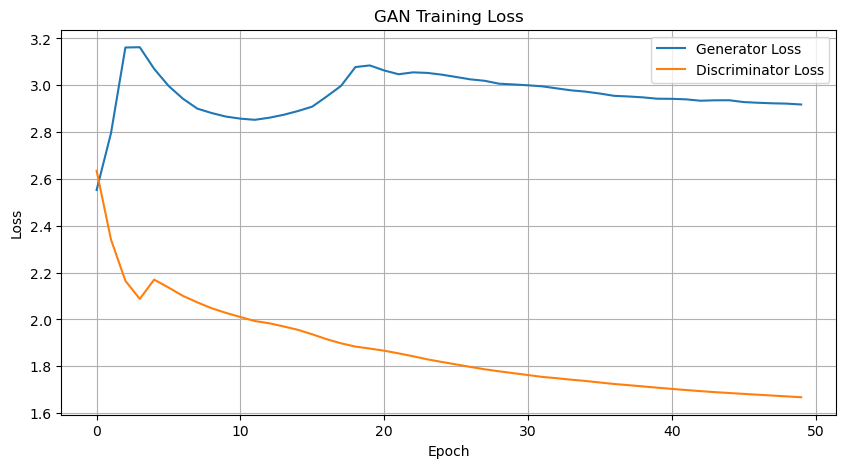

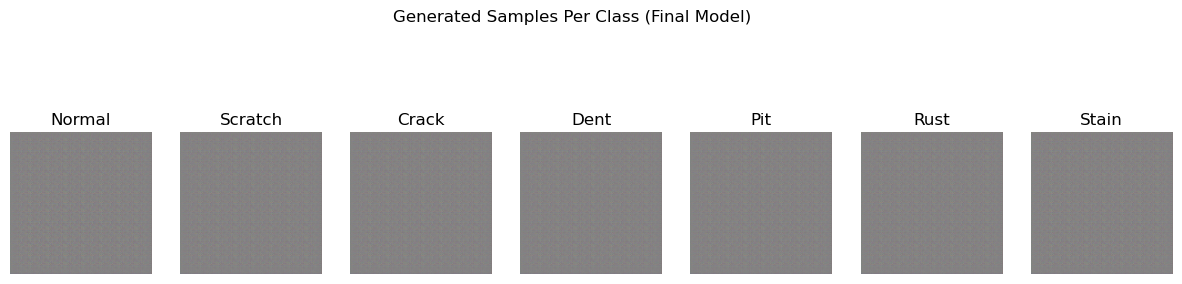

In [13]:
# =========================================================
# MODULE 6 — TRAINING LOOP
# =========================================================

import matplotlib.pyplot as plt

def save_samples(epoch):
    r, c = 2, NUM_CLASSES
    noise = np.random.normal(0, 1, (c, LATENT_DIM))
    labels = np.arange(0, NUM_CLASSES).reshape(-1,1)

    gen_imgs = generator.predict([noise, labels])
    gen_imgs = 0.5 * gen_imgs + 0.5

    fig, axs = plt.subplots(r, c, figsize=(15,6))
    for i in range(c):
        axs[0, i].imshow(gen_imgs[i])
        axs[0, i].set_title(LABEL_MAP[i])
        axs[0, i].axis('off')

    plt.savefig(f"{SAMPLE_DIR}/epoch_{epoch}.png")
    plt.close()

# =========================================================
# LIVE TRAINING VISUALIZATION SETUP
# =========================================================

import matplotlib.pyplot as plt
from IPython.display import clear_output

g_losses = []
d_losses = []

def plot_progress(epoch, gen_imgs):
    clear_output(wait=True)

    plt.figure(figsize=(15,5))

    # -------------------
    # Loss Curve
    # -------------------
    plt.subplot(1,2,1)
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.legend()
    plt.title(f"Training Loss - Epoch {epoch}")

    # -------------------
    # Generated Images
    # -------------------
    plt.subplot(1,2,2)
    gen_imgs = 0.5 * gen_imgs + 0.5
    plt.imshow(gen_imgs[0])
    plt.title("Generated Sample")
    plt.axis('off')

    plt.show()

def train():

    real = np.ones((BATCH_SIZE, 1)) * 0.9
    fake = np.zeros((BATCH_SIZE, 1))

    for epoch in range(EPOCHS):

        # ===============================
        # Train Discriminator
        # ===============================
        discriminator.trainable = True

        imgs, labels = next(train_data)
        labels = labels.reshape(-1, 1)

        noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
        sampled_labels = np.random.randint(0, NUM_CLASSES, BATCH_SIZE).reshape(-1,1)

        gen_imgs = generator.predict([noise, sampled_labels], verbose=0)

        d_loss_real = discriminator.train_on_batch(imgs, [real, labels])
        d_loss_fake = discriminator.train_on_batch(gen_imgs, [fake, sampled_labels])

        d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])

        # ===============================
        # Train Generator
        # ===============================
        discriminator.trainable = False

        noise = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
        sampled_labels = np.random.randint(0, NUM_CLASSES, BATCH_SIZE).reshape(-1,1)

        g_loss = combined_model.train_on_batch(
            [noise, sampled_labels],
            [real, sampled_labels]
        )

        # Store losses
        g_losses.append(g_loss[0])
        d_losses.append(d_loss)
        

        # ===============================
        # Display Every 5 Epochs
        # ===============================
        if epoch % 5 == 0:
            sample_noise = np.random.normal(0,1,(1,LATENT_DIM))
            sample_label = np.array([[0]])
            sample_img = generator.predict([sample_noise, sample_label], verbose=0)

            plot_progress(epoch, sample_img)

        print(f"Epoch {epoch}/{EPOCHS} | D: {d_loss:.4f} | G: {g_loss[0]:.4f}")

# =========================================================
# FINAL VISUALIZATION AFTER TRAINING
# =========================================================

import matplotlib.pyplot as plt

def final_visualization():

    # ----------------------------
    # Plot Loss Curves
    # ----------------------------
    plt.figure(figsize=(10,5))
    plt.plot(g_losses, label='Generator Loss')
    plt.plot(d_losses, label='Discriminator Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ----------------------------
    # Generate One Image Per Class
    # ----------------------------
    noise = np.random.normal(0,1,(NUM_CLASSES, LATENT_DIM))
    labels = np.arange(0, NUM_CLASSES).reshape(-1,1)

    gen_imgs = generator.predict([noise, labels], verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5

    plt.figure(figsize=(15,4))
    for i in range(NUM_CLASSES):
        plt.subplot(1, NUM_CLASSES, i+1)
        plt.imshow(gen_imgs[i])
        plt.title(LABEL_MAP[i])
        plt.axis("off")

    plt.suptitle("Generated Samples Per Class (Final Model)")
    plt.show()


train()

final_visualization()



In [16]:
# =========================================================
# MODULE 7 — STREAMLIT APP
# =========================================================

import streamlit as st
from tensorflow.keras.models import load_model

st.title("Surface Defect Synthetic Generator")

model = load_model(r"C:\Users\drsas\Project5\CheckPoints\G_epoch_50.keras")


def generate_images(defect_class, count):
    noise = np.random.normal(0,1,(count, LATENT_DIM))
    labels = np.full((count,1), defect_class)
    imgs = model.predict([noise, labels])
    imgs = 0.5 * imgs + 0.5
    return imgs

selected_defect = st.selectbox("Select Defect Type", list(LABEL_MAP.values()))
count = st.slider("Number of Images", 1, 20, 5)

if st.button("Generate"):
    class_id = list(LABEL_MAP.keys())[list(LABEL_MAP.values()).index(selected_defect)]
    images = generate_images(class_id, count)

    for img in images:
        st.image(img, use_column_width=True)


2026-02-12 07:29:28.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29:28.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29:28.272 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29:28.273 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29:28.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29:28.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29:28.276 Session state does not function when running a script without `streamlit run`
2026-02-12 07:29:28.277 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-12 07:29

Found 1725 images belonging to 3 classes.
Found 1725 images belonging to 3 classes.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)          │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_13 (ReLU)                      │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_14 (ReLU)                      │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_15 (ReLU)                      │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │       4,194,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289,479 (16.36 MB)

 Trainable params: 4,289,031 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 587ms/step - accuracy: 0.9652 - loss: 0.8244 - val_accuracy: 0.6667 - val_loss: 12.7247
Epoch 2/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 565ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.4400 - val_loss: 37.1848
Epoch 3/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 557ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.6667 - val_loss: 35.6506
Epoch 4/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 561ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.6667 - val_loss: 31.4530
Epoch 5/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 555ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.6667 - val_loss: 20.8255
Epoch 6/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 31s 568ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9490 - val_loss: 0.9488
Epoch 7/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 552ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.9983 - val_loss: 0.0146
Epoch 8/15
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 557ms/step - accuracy: 1.0

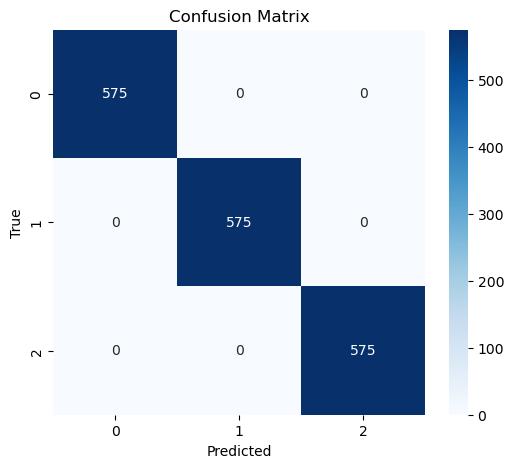

In [21]:
# =========================================================
# MODULE 8 — DEFECT CLASSIFIER (FULL TRAIN + EVALUATE)
# =========================================================

from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# -----------------------------
# 1️⃣ Data Loaders
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0
)

test_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0
)
Train_Data_Directory = r"C:\Users\drsas\Project5\Rawdata\SurfaceDefectDataNew\DAGM_KaggleCombined\train"

train_loader = train_datagen.flow_from_directory(
    Train_Data_Directory,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

Test_Data_Directory = r"C:\Users\drsas\Project5\Rawdata\SurfaceDefectDataNew\DAGM_KaggleCombined\test"

test_loader = test_datagen.flow_from_directory(
    Test_Data_Directory,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# -----------------------------
# 2️⃣ Build Classifier
# -----------------------------
def build_classifier():

    inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
    x = inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, output)

classifier = build_classifier()

classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

classifier.summary()

# -----------------------------
# 3️⃣ Train Classifier
# -----------------------------
history = classifier.fit(
    train_loader,
    epochs=15,
    validation_data=test_loader
)

# -----------------------------
# 4️⃣ Evaluate
# -----------------------------
test_loss, test_acc = classifier.evaluate(test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 5️⃣ Classification Report
# -----------------------------
preds = classifier.predict(test_loader)
y_pred = np.argmax(preds, axis=1)
y_true = test_loader.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

# -----------------------------
# 6️⃣ Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
